In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


Dataset shape: (506, 14)

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Basic stats:
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD 

/tmp/ipykernel_4425/1107517719.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


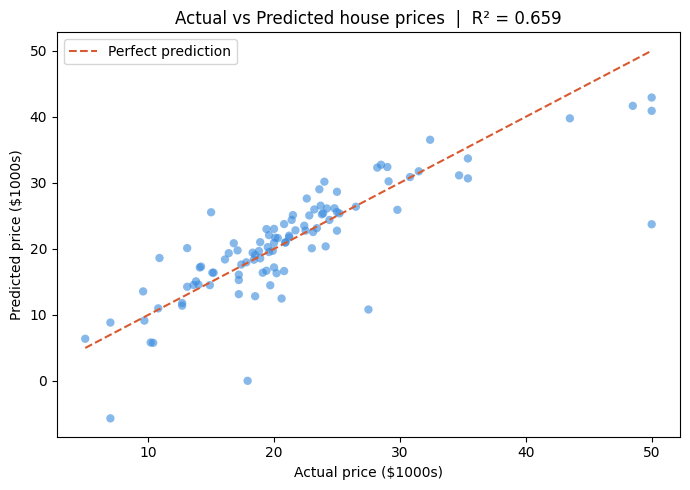

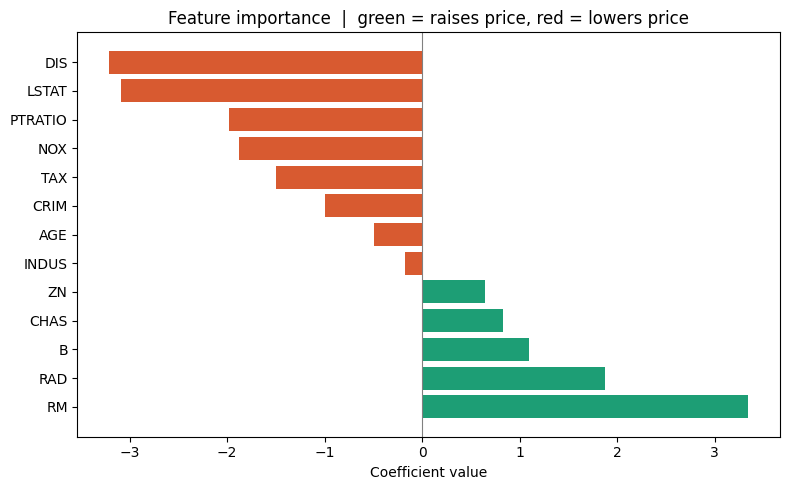

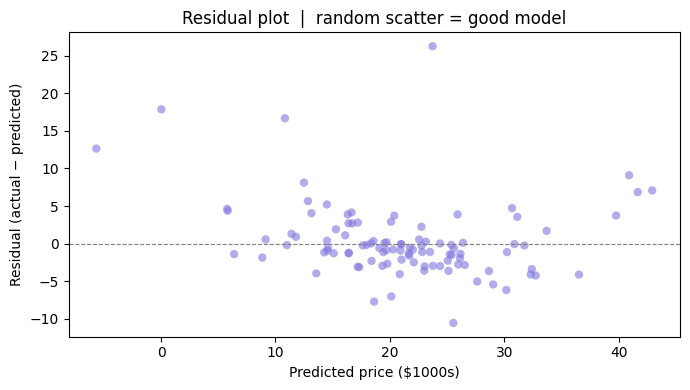


── Sample predictions (first 10 test rows) ────────
 Actual ($1000s)  Predicted ($1000s)  Error ($1000s)
            23.6                29.0            -5.4
            32.4                36.5            -4.1
            13.6                14.5            -0.9
            22.8                25.1            -2.3
            16.1                18.4            -2.3
            20.0                23.0            -3.0
            17.8                18.0            -0.2
            14.0                14.6            -0.6
            19.6                22.1            -2.5
            16.8                20.9            -4.1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── 1. LOAD DATA ──────────────────────────────────────────
# Change filename below if your file has a different name
df = pd.read_csv("HousingData.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe().round(2))

# ── 2. HANDLE MISSING VALUES ──────────────────────────────
# Boston Housing on some Kaggle versions has a few nulls
# Fill each column's nulls with that column's median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled nulls in: {col}")

print("\nMissing values after fill:", df.isnull().sum().sum())

# ── 3. SPLIT FEATURES AND TARGET ──────────────────────────
# MEDV = median house value in $1000s — this is what we predict
# Some Kaggle versions use lowercase column names
target_col = "MEDV" if "MEDV" in df.columns else "medv"

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nTarget column : {target_col}")
print(f"Features      : {list(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ── 4. TRAIN / TEST SPLIT ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain rows: {len(X_train)}, Test rows: {len(X_test)}")

# ── 5. SCALE FEATURES ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + scale on train
X_test_sc  = scaler.transform(X_test)       # scale only on test

# ── 6. TRAIN MODEL ────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_sc, y_train)
print("\nModel trained successfully.")

# ── 7. EVALUATE ON TEST SET ───────────────────────────────
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("\n── Model Performance ──────────────────────────────")
print(f"R² Score  : {r2:.4f}   (1.0 = perfect, 0 = no better than mean)")
print(f"RMSE      : {rmse:.4f}  (avg error in $1000s)")
print(f"MAE       : {mae:.4f}  (mean absolute error in $1000s)")

# ── 8. FEATURE COEFFICIENTS ───────────────────────────────
coeff_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("\n── Feature Coefficients (sorted) ──────────────────")
print(coeff_df.to_string(index=False))
print("\nPositive = raises price | Negative = lowers price")

# ── 9. PLOT 1 — Actual vs Predicted ──────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color="#378ADD", edgecolors="none")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#D85A30", linewidth=1.5, linestyle="--", label="Perfect prediction")
plt.xlabel("Actual price ($1000s)")
plt.ylabel("Predicted price ($1000s)")
plt.title(f"Actual vs Predicted house prices  |  R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# ── 10. PLOT 2 — Feature coefficients bar chart ───────────
plt.figure(figsize=(8, 5))
colors = ["#1D9E75" if c > 0 else "#D85A30" for c in coeff_df["Coefficient"]]
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"], color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Coefficient value")
plt.title("Feature importance  |  green = raises price, red = lowers price")
plt.tight_layout()
plt.show()

# ── 11. PLOT 3 — Residuals ────────────────────────────────
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.6, color="#7F77DD", edgecolors="none")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Predicted price ($1000s)")
plt.ylabel("Residual (actual − predicted)")
plt.title("Residual plot  |  random scatter = good model")
plt.tight_layout()
plt.show()

# ── 12. SAMPLE PREDICTIONS ───────────────────────────────
results = pd.DataFrame({
    "Actual ($1000s)":    y_test.values[:10].round(1),
    "Predicted ($1000s)": y_pred[:10].round(1),
    "Error ($1000s)":    (y_test.values[:10] - y_pred[:10]).round(1)
})
print("\n── Sample predictions (first 10 test rows) ────────")
print(results.to_string(index=False))